In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [3]:
load_dotenv()

True

In [4]:
model = ChatGroq(model = "openai/gpt-oss-120b")

In [ ]:
class Sentimentschema(BaseModel):  # To create structured output for the model
    sentiment: Literal["positive", "negative"] = Field( description="sentiment of the review")

In [15]:
# Schema for run_dignosis for structured output

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [16]:
structured_model = model.with_structured_output(Sentimentschema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [9]:
prompt = 'What is the sentimaent of the following  review - The software is to bed'

structured_model.invoke(prompt).sentiment

'negative'

In [10]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [17]:
def fined_sentiment(state: ReviewState):

    prompt = f'For the following review find out sentiment \n {state['review']}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}


def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state: ReviewState):

     prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
     response = model.invoke(prompt).content

     return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}  # Json will convert into dict and store in diagnosis key of state

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}


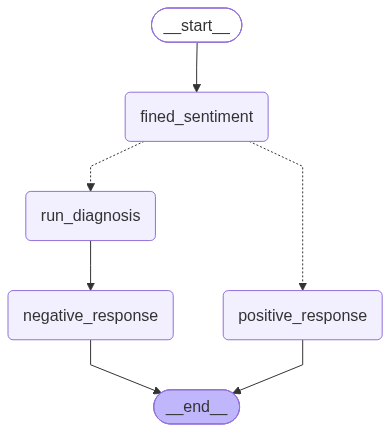

In [20]:
graph = StateGraph(ReviewState)

graph.add_node('fined_sentiment', fined_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)


graph.add_edge(START, 'fined_sentiment')

graph.add_conditional_edges('fined_sentiment', check_sentiment)
graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

workflow


In [21]:
intial_state = { 'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."}

workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': 'Hi\u202f[Customer Name],\n\nI’m really sorry you’re experiencing this bug—it’s completely understandable why you’d be frustrated, especially when things aren’t working as they should. I appreciate you letting us know, and I’m treating this as a top‑priority issue so we can get it resolved for you as quickly as possible.\n\n**Here’s what we’ll do right now:**\n\n1. **Gather the details we need**  \n   Could you please share the following information (if you haven’t already)?  \n   - The exact steps you took before the bug appeared.  \n   - Any error messages or screenshots you can provide.  \n   - The device, operating system, and app 